# Verifying Heston variational equation with the Heston tree

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from heston.tree import HestonTreeFast
from heston.closed import heston_call_price

In [3]:
S0 = 100.0   # Initial stock price
K = 100.0    # Strike price
T = 0.5      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

option_type = "call"

In [4]:
n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.8
S0_max = S0 * 1.2

heston_tree = HestonTreeFast(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min, S0_max=S0_max,
                       option_type=option_type, exercise_type="european")

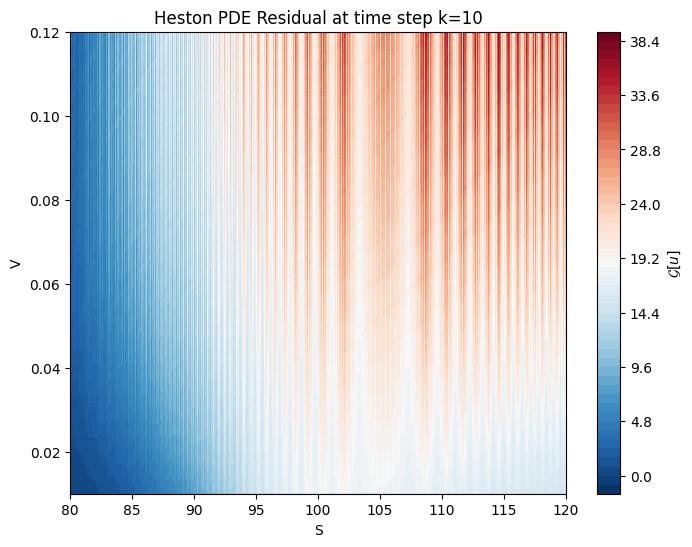

In [6]:
# Parameters for the grid
S_min, S_max, S_steps = S0_min, S0_max, mz   # adjust to your needs
V_min, V_max, V_steps = V0_min, V0_max, mv

S_grid = np.linspace(S_min, S_max, S_steps)
V_grid = np.linspace(V_min, V_max, V_steps)

# Time step
k = 10
dt = heston_tree.dt  # or compute from your tree

# Allocate arrays for prices
U_t = np.zeros((S_steps, V_steps))
U_tplus = np.zeros_like(U_t)

# Fill price arrays
for j, V in enumerate(V_grid):
    U_t[:, j] = heston_tree.price(V, S_grid, k)       # vector over S, scalar V
    U_tplus[:, j] = heston_tree.price(V, S_grid, k+1)

# Step sizes
dS = S_grid[1] - S_grid[0]
dV = V_grid[1] - V_grid[0]

# Compute derivatives
dU_dt = (U_tplus - U_t) / dt

# Central differences
dU_dS = np.zeros_like(U_t)
d2U_dS2 = np.zeros_like(U_t)
dU_dV = np.zeros_like(U_t)
d2U_dV2 = np.zeros_like(U_t)
d2U_dSdV = np.zeros_like(U_t)

# S derivatives (central)
dU_dS[1:-1,:] = (U_t[2:,:] - U_t[:-2,:]) / (2*dS)
d2U_dS2[1:-1,:] = (U_t[2:,:] - 2*U_t[1:-1,:] + U_t[:-2,:]) / (dS**2)

# V derivatives (central)
dU_dV[:,1:-1] = (U_t[:,2:] - U_t[:,:-2]) / (2*dV)
d2U_dV2[:,1:-1] = (U_t[:,2:] - 2*U_t[:,1:-1] + U_t[:,:-2]) / (dV**2)

# Cross derivative (central)
d2U_dSdV[1:-1,1:-1] = (
    U_t[2:,2:] - U_t[2:,:-2] - U_t[:-2,2:] + U_t[:-2,:-2]
) / (4*dS*dV)

# Meshgrid for L operator
S_mesh, V_mesh = np.meshgrid(S_grid, V_grid, indexing='ij')

# Heston params
r     = heston_tree.r
kappa = heston_tree.kappa
theta = heston_tree.theta
sigma = heston_tree.sigma
rho   = heston_tree.rho

# Operator L
L = (r * S_mesh * dU_dS +
     kappa*(theta - V_mesh) * dU_dV +
     0.5 * (S_mesh**2 * V_mesh * d2U_dS2 +
            2*rho*sigma*S_mesh*V_mesh*d2U_dSdV +
            sigma**2*V_mesh*d2U_dV2))

# Residual
G = r*U_t - dU_dt + L

# Heatmap
plt.figure(figsize=(8,6))
plt.contourf(S_mesh, V_mesh, G, levels=50, cmap='RdBu_r')
plt.colorbar(label=r'$\mathcal{G}[u]$')
plt.xlabel('S')
plt.ylabel('V')
plt.title(f'Heston PDE Residual at time step k={k}')
plt.show()

## For closed form

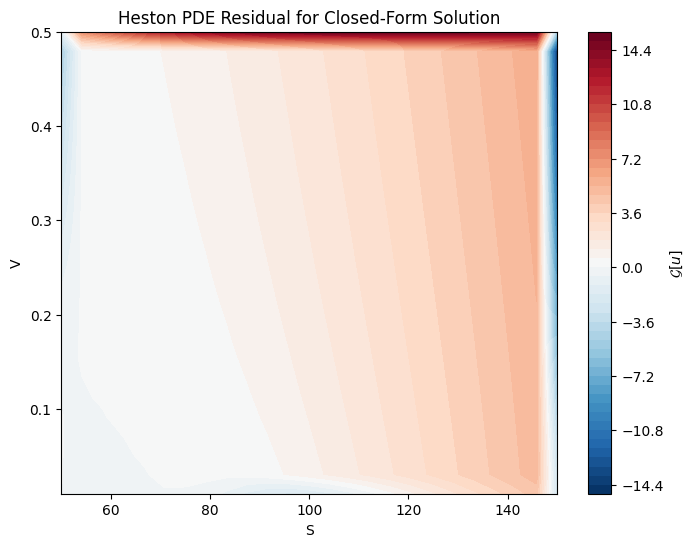

In [9]:
S_min, S_max, S_steps = 50, 150, 25
V_min, V_max, V_steps = 0.01, 0.5, 25

S_grid = np.linspace(S_min, S_max, S_steps)
V_grid = np.linspace(V_min, V_max, V_steps)
dS = S_grid[1] - S_grid[0]
dV = V_grid[1] - V_grid[0]

S_mesh, V_mesh = np.meshgrid(S_grid, V_grid, indexing='ij')

# Heston parameters
K = 100
T = 1.0
r = 0.05
kappa = 1.5
theta = 0.04
sigma = 0.3
rho = -0.7

# -----------------------------
# Time derivative approx
# -----------------------------
dt = 1e-4  # small time step for numerical derivative
U_t     = np.zeros_like(S_mesh)
U_tplus = np.zeros_like(S_mesh)

for i, S in enumerate(S_grid):
    for j, V in enumerate(V_grid):
        U_t[i,j]     = heston_call_price(S, K, T, r, kappa, theta, sigma, rho, V)
        # approximate price a tiny dt later
        U_tplus[i,j] = heston_call_price(S, K, T-dt, r, kappa, theta, sigma, rho, V)

dU_dt = (U_tplus - U_t) / (-dt)  # minus because T-dt

# -----------------------------
# Finite differences for S and V
# -----------------------------
dU_dS  = np.zeros_like(U_t)
d2U_dS2 = np.zeros_like(U_t)
dU_dV  = np.zeros_like(U_t)
d2U_dV2 = np.zeros_like(U_t)
d2U_dSdV = np.zeros_like(U_t)

# S derivatives (central)
dU_dS[1:-1,:] = (U_t[2:,:] - U_t[:-2,:]) / (2*dS)
d2U_dS2[1:-1,:] = (U_t[2:,:] - 2*U_t[1:-1,:] + U_t[:-2,:]) / (dS**2)

# V derivatives (central)
dU_dV[:,1:-1] = (U_t[:,2:] - U_t[:,:-2]) / (2*dV)
d2U_dV2[:,1:-1] = (U_t[:,2:] - 2*U_t[:,1:-1] + U_t[:,:-2]) / (dV**2)

# Cross derivative
d2U_dSdV[1:-1,1:-1] = (
    U_t[2:,2:] - U_t[2:,:-2] - U_t[:-2,2:] + U_t[:-2,:-2]
) / (4*dS*dV)

# -----------------------------
# PDE operator
# -----------------------------
L = (r * S_mesh * dU_dS +
     kappa*(theta - V_mesh) * dU_dV +
     0.5 * (S_mesh**2 * V_mesh * d2U_dS2 +
            2*rho*sigma*S_mesh*V_mesh*d2U_dSdV +
            sigma**2*V_mesh*d2U_dV2))

G = r*U_t - dU_dt + L

# -----------------------------
# Heatmap of residual
# -----------------------------
plt.figure(figsize=(8,6))
plt.contourf(S_mesh, V_mesh, G, levels=50, cmap='RdBu_r')
plt.colorbar(label=r'$\mathcal{G}[u]$')
plt.xlabel('S')
plt.ylabel('V')
plt.title('Heston PDE Residual for Closed-Form Solution')
plt.show()